In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [3]:
df = pd.DataFrame(housing.data , columns=housing.feature_names)
df['MedHouseValue'] = housing.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


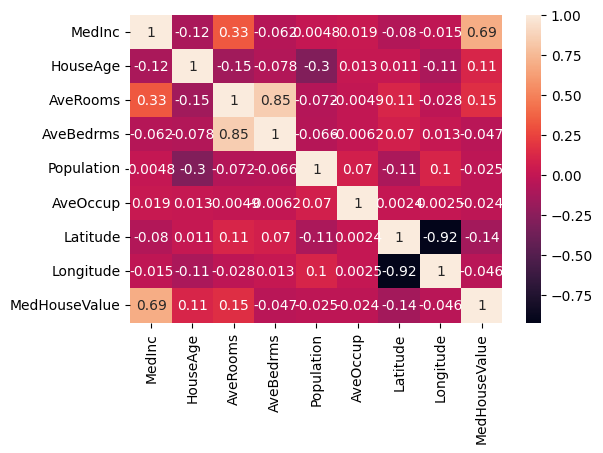

In [6]:
# correlation
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True)
plt.show()

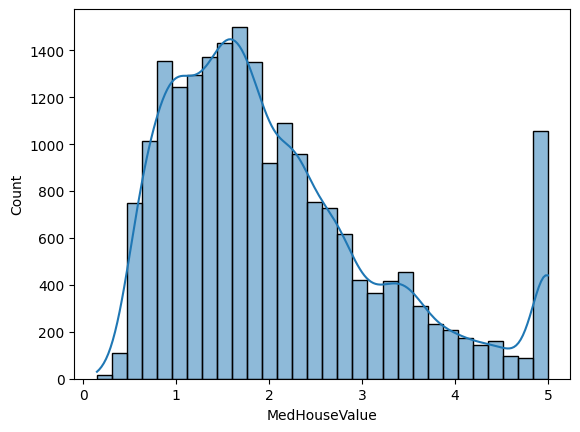

In [7]:
# Target Distribution
sns.histplot(df['MedHouseValue'], bins=30, kde=True)
plt.show()

**Model Training**

In [9]:
# Linear Regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df.drop("MedHouseValue",axis=1)
y = df["MedHouseValue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [11]:
# Predication
y_pred = model.predict(X_test)
print("predication:",y_pred)

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251])

In [12]:
# check Score
from sklearn.metrics import r2_score
print("R2 Score :",r2_score(y_test,y_pred))

R2 Score : 0.5757877060324508


**Random Forest Regression**

In [15]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100 , random_state=42)
rf.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [16]:
# predication +score
y_pred_rf=rf.predict(X_test)

from sklearn.metrics import r2_score
print("Random Forest R2 :",r2_score(y_test,y_pred_rf))

Random Forest R2 : 0.8051230593157366


In [17]:
# Which features affect house price most?

importance = rf.feature_importances_

features = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

print(features)

      feature  importance
0      MedInc    0.524871
5    AveOccup    0.138443
6    Latitude    0.088936
7   Longitude    0.088629
1    HouseAge    0.054593
2    AveRooms    0.044272
4  Population    0.030650
3   AveBedrms    0.029606


“Random Forest performed better (R² = 0.80) compared to Linear Regression (R² = 0.57), indicating the presence of non-linear relationships in the dataset. Feature importance analysis showed that Median Income is the strongest predictor of house prices.”